In [1]:
from google.colab import drive

drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
import os
import pandas as pd
import shutil

In [3]:
root = "/content/gdrive/MyDrive/Jurnal/Jurnal_Alt"
rootdata = "/content/gdrive/MyDrive/Jurnal/Jurnal_Alt/dataset"
# if os.path.exists(rootdata) == True :
#     shutil.rmtree(root + "/dataset/")

# os.mkdir(root + '/dataset')
# os.mkdir(root + '/dataset/train')
# os.mkdir(root + '/dataset/val')
# os.mkdir(root + '/dataset/train/Anggur')
# os.mkdir(root + '/dataset/train/Apel')
# os.mkdir(root + '/dataset/train/Apricot')
# os.mkdir(root + '/dataset/train/Ceri')
# os.mkdir(root + '/dataset/train/Jambu')
# os.mkdir(root + '/dataset/train/Lemon')
# os.mkdir(root + '/dataset/train/Mangga')
# os.mkdir(root + '/dataset/train/Peach')
# os.mkdir(root + '/dataset/train/Pir')
# os.mkdir(root + '/dataset/val/Anggur')
# os.mkdir(root + '/dataset/val/Apel')
# os.mkdir(root + '/dataset/val/Apricot')
# os.mkdir(root + '/dataset/val/Ceri')
# os.mkdir(root + '/dataset/val/Jambu')
# os.mkdir(root + '/dataset/val/Lemon')
# os.mkdir(root + '/dataset/val/Mangga')
# os.mkdir(root + '/dataset/val/Peach')
# os.mkdir(root + '/dataset/val/Pir')

In [4]:
# import random
# from shutil import copyfile

# def train_val_split(source, train, val, train_ratio):
#   total_size = len(os.listdir(source))
#   train_size = int(train_ratio * total_size)
#   val_size = total_size - train_size

#   randomized = random.sample(os.listdir(source), total_size)
#   train_files = randomized[0:train_size]
#   val_files = randomized[train_size:total_size]

#   for i in train_files:
#     i_file = source + i
#     destination = train + i
#     copyfile(i_file, destination)

#   for i in val_files:
#     i_file = source + i
#     destination = val + i
#     copyfile(i_file, destination)

# train_ratio = 0.8

# #Pembagian Training dan validasi

# source_00 = root + '/Daun/Anggur/'
# train_00 = root + '/dataset/train/Anggur/'
# val_00 = root + '/dataset/val/Anggur/'
# train_val_split(source_00, train_00, val_00, train_ratio)

# source_01 = root + '/Daun/Apel/'
# train_01 = root + '/dataset/train/Apel/'
# val_01 = root + '/dataset/val/Apel/'
# train_val_split(source_01, train_01, val_01, train_ratio)

# source_02 = root + '/Daun/Apricot/'
# train_02 = root + '/dataset/train/Apricot/'
# val_02 = root + '/dataset/val/Apricot/'
# train_val_split(source_02, train_02, val_02, train_ratio)

# source_03 = root + '/Daun/Ceri/'
# train_03 = root + '/dataset/train/Ceri/'
# val_03 = root + '/dataset/val/Ceri/'
# train_val_split(source_03, train_03, val_03, train_ratio)

# source_04 = root + '/Daun/Jambu/'
# train_04 = root + '/dataset/train/Jambu/'
# val_04 = root + '/dataset/val/Jambu/'
# train_val_split(source_04, train_04, val_04, train_ratio)

# source_05 = root + '/Daun/Lemon/'
# train_05 = root + '/dataset/train/Lemon/'
# val_05 = root + '/dataset/val/Lemon/'
# train_val_split(source_05, train_05, val_05, train_ratio)

# source_06 = root + '/Daun/Mangga/'
# train_06 = root + '/dataset/train/Mangga/'
# val_06 = root + '/dataset/val/Mangga/'
# train_val_split(source_06, train_06, val_06, train_ratio)

# source_07 = root + '/Daun/Peach/'
# train_07 = root + '/dataset/train/Peach/'
# val_07 = root + '/dataset/val/Peach/'
# train_val_split(source_07, train_07, val_07, train_ratio)

# source_08 = root + '/Daun/Pir/'
# train_08 = root + '/dataset/train/Pir/'
# val_08 = root + '/dataset/val/Pir/'
# train_val_split(source_08, train_08, val_08, train_ratio)

In [5]:
# print('Jumlah All Anggur     :', len(os.listdir(root + 'Daun/Anggur')))
# print('Jumlah Train Anggur   :', len(os.listdir(root + '/dataset/train/Anggur')))
# print('Jumlah val Anggur     :', len(os.listdir(root + '/dataset/val/Anggur')))

In [6]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [7]:
train_datagen = ImageDataGenerator(
                  rescale = 1./255.,
                  rotation_range = 30,
                  horizontal_flip = True,
                  shear_range = 0.3,
                  fill_mode = 'nearest',
                  width_shift_range = 0.2,
                  height_shift_range = 0.2,
                  zoom_range = 0.1
)

val_datagen = ImageDataGenerator(
                rescale = 1./255.,
                rotation_range = 30,
                horizontal_flip = True,
                shear_range = 0.3,
                fill_mode = 'nearest',
                width_shift_range = 0.2,
                height_shift_range = 0.2,
                zoom_range = 0.1
)

In [8]:
train_dir = root + '/dataset/train/'
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size = (150, 150),
    batch_size = 30,
    class_mode = 'categorical'
)

val_dir = root + '/dataset/val/'
val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size = (150, 150),
    batch_size = 30,
    class_mode = 'categorical'
)

Found 1284 images belonging to 9 classes.
Found 324 images belonging to 9 classes.


In [9]:
# callbacks
class myCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs = {}):
    if(logs.get('accuracy') > 0.99):
      print('\nAkurasi mencapai 99%')
      self.model.stop_training = True

callbacks = myCallback()

In [10]:
  model = tf.keras.models.Sequential([
            tf.keras.layers.Conv2D(32, (3, 3), activation = 'relu', input_shape = (150, 150, 3)),
            tf.keras.layers.MaxPooling2D(2, 2),
            tf.keras.layers.Conv2D(64, (3, 3), activation = 'relu'),
            tf.keras.layers.MaxPooling2D(2, 2),
            tf.keras.layers.Conv2D(32, (3, 3), activation = 'relu'),
            tf.keras.layers.MaxPooling2D(2, 2),
            tf.keras.layers.Flatten(),
            tf.keras.layers.Dense(200, activation = 'relu'),
            tf.keras.layers.Dropout(0.3,seed=112),
            tf.keras.layers.Dense(500, activation = 'relu'),
            tf.keras.layers.Dropout(0.5,seed=112),
            tf.keras.layers.Dense(9, activation = 'softmax')
  ])

In [11]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 148, 148, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 74, 74, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 72, 72, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 36, 36, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 34, 34, 32)        18464     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 17, 17, 32)       0

In [12]:
from keras import backend as K

def recall_m(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    recall = true_positives / (possible_positives + K.epsilon())
    return recall

def precision_m(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    return precision

def f1_m(y_true, y_pred):
    precision = precision_m(y_true, y_pred)
    recall = recall_m(y_true, y_pred)
    return 2*((precision*recall)/(precision+recall+K.epsilon()))

In [13]:
model.compile(loss = 'categorical_crossentropy',
              optimizer = 'Adam',
              metrics = ['accuracy', f1_m,precision_m, recall_m])

In [14]:
history = model.fit(
            train_generator,
            steps_per_epoch = 20,
            epochs = 100,
            validation_data = val_generator,
            validation_steps = 5,
            verbose = 1,
            callbacks = [callbacks]
)


Epoch 1/100
20/20 [==============================] - 190s 9s/step - loss: 2.1231 - accuracy: 0.2067 - f1_m: 0.0031 - precision_m: 0.0250 - recall_m: 0.0017 - val_loss: 2.0656 - val_accuracy: 0.3867 - val_f1_m: 0.0000e+00 - val_precision_m: 0.0000e+00 - val_recall_m: 0.0000e+00
Epoch 2/100
20/20 [==============================] - 98s 5s/step - loss: 1.9735 - accuracy: 0.2933 - f1_m: 0.0753 - precision_m: 0.4190 - recall_m: 0.0433 - val_loss: 1.7172 - val_accuracy: 0.3667 - val_f1_m: 0.3590 - val_precision_m: 0.5546 - val_recall_m: 0.2667
Epoch 3/100
20/20 [==============================] - 55s 3s/step - loss: 1.5883 - accuracy: 0.3900 - f1_m: 0.3027 - precision_m: 0.6767 - recall_m: 0.2050 - val_loss: 1.2846 - val_accuracy: 0.5133 - val_f1_m: 0.4124 - val_precision_m: 0.7877 - val_recall_m: 0.2800
Epoch 4/100
20/20 [==============================] - 29s 1s/step - loss: 1.2231 - accuracy: 0.5567 - f1_m: 0.4205 - precision_m: 0.6686 - recall_m: 0.3133 - val_loss: 1.0299 - val_accuracy: 0.

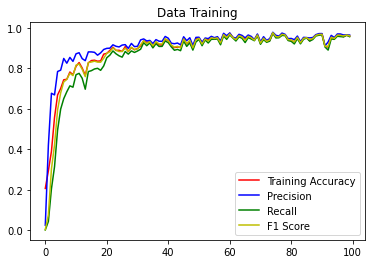

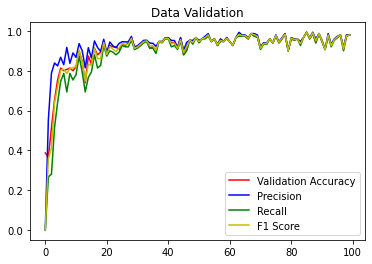

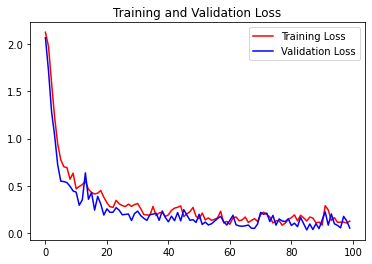

In [15]:
%matplotlib inline

import matplotlib.image  as mpimg
import matplotlib.pyplot as plt


acc = history.history['accuracy']
rec_train = history.history['recall_m']
pres_train = history.history['precision_m']
f1_train = history.history['f1_m']
val_acc = history.history['val_accuracy']
rec_val = history.history['val_recall_m']
pres_val = history.history['val_precision_m']
f1_val = history.history['val_f1_m']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r', label = 'Training Accuracy')
plt.plot(epochs, pres_train, 'b', label = 'Precision')
plt.plot(epochs, rec_train, 'g', label = 'Recall')
plt.plot(epochs, f1_train, 'y', label = 'F1 Score')
plt.title('Data Training')
plt.legend(loc = 'best')
plt.show()

plt.plot(epochs, val_acc, 'r', label = 'Validation Accuracy')
plt.plot(epochs, pres_val, 'b', label = 'Precision')
plt.plot(epochs, rec_val, 'g', label = 'Recall')
plt.plot(epochs, f1_val, 'y', label = 'F1 Score')
plt.title('Data Validation')
plt.legend(loc = 'best')
plt.show()

plt.plot(epochs, loss, 'r', label = 'Training Loss')
plt.plot(epochs, val_loss, 'b', label = 'Validation Loss')
plt.title('Training and Validation Loss')
plt.legend(loc = 'best')
plt.show()